This notebook begins the modeling phase of our Facebook Metrics project.
All preprocessing steps have already been completed in preprocessing.ipynb, including:

Handling missing values , removing redundant / highly correlated columns, encoding categorical variables, scaling numerical features, saving the cleaned dataset to processed/facebook_cleaned.csv

In this notebook, we will:

- Load the cleaned dataset
- Define our target variable (y) and features (X)
- Create a train/test split
- Train a baseline model
- Evaluate performance
- Review feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Loading the cleaned dataset

data = pd.read_csv("../processed/facebook_cleaned.csv")

In [11]:
data.columns

Index(['Lifetime Post Total Reach', 'Lifetime Engaged Users',
       'Lifetime Post Consumers',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'comment', 'like', 'share', 'Type_Photo', 'Type_Status', 'Type_Video',
       'Category_2', 'Category_3', 'Post Month_2', 'Post Month_3',
       'Post Month_4', 'Post Month_5', 'Post Month_6', 'Post Month_7',
       'Post Month_8', 'Post Month_9', 'Post Month_10', 'Post Month_11',
       'Post Month_12', 'Post Weekday_2', 'Post Weekday_3', 'Post Weekday_4',
       'Post Weekday_5', 'Post Weekday_6', 'Post Weekday_7', 'Post Hour_2',
       'Post Hour_3', 'Post Hour_4', 'Post Hour_5', 'Post Hour_6',
       'Post Hour_7', 'Post Hour_8', 'Post Hour_9', 'Post Hour_10',
       'Post Hour_11', 'Post Hour_12', 'Post Hour_13', 'Post Hour_14',
       'Post Hour_15', 'Post Hour_16', 'Post Ho

In [ ]:
#Train/ Test Split 
#We chose 'like' because 'like' is the most stable/ computable metric to evaluate. 


X = data.drop(columns=['like'])
y = data['like']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Our supervised model is trying to predict the number of likes a Facebook post receives based on all the other features (reach & impression features, comments, shares, post type, and post metadata features).

**Random Forest Regressor Model**

In [ ]:
#We use RandomForestRegressor model first as a baseline because our data has mixed feature types and our variable 'like' is a nonlinear feature.

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
#Then Evaluate

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)


MAE: 0.19444093780244479
RMSE: 0.4610121390176264
R^2: 0.5164342223779319


*Results*

Our results show us how well does the model predict the number of likes a post will get. 
MAE: 0.1944 , on average our model's predictions are off by 0.19 units of our target variable. Our model then is reasonably accurate but not perfect.

RMSE: 0.4610 , model occassionally can ,ale larger errors than the MAE suggests. Some posts may be harder to predit or there may be outliers or unusal posts (viral posts, paid videos, paid posts, etc.)

R^2: 0.5164 , shows us how much variation our target variable model can explain. Which is about half of the variation in likes. 

**K-Means Clustering**

To complement our supervised modeling, we apply an unsupervised technique — "K-Means clustering" — to uncover natural groupings within our Facebook posts. Clustering helps us understand structural patterns in engagement and reach metrics that are not directly visible from the raw data. Unlike dimensionality reduction, clustering produces meaningful grouping labels that we can add back into our dataset as a new feature. Dimensionality reduction compresses features, but does not create useful features for modeling. These cluster labels may improve the performance of our supervised models by giving them additional information about underlying groups.

In [12]:
#Import additional packages

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Selected Features for Clustering
cluster_features = [
    'Lifetime Post Total Reach',
    'Lifetime Engaged Users',
    'Lifetime Post Consumers',
    'Lifetime Post Impressions by people who have liked your Page',
    'Lifetime Post reach by people who like your Page',
    'Lifetime People who have liked your Page and engaged with your post',
    'comment',
    'share'
]

X_cluster = data[cluster_features]

#Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


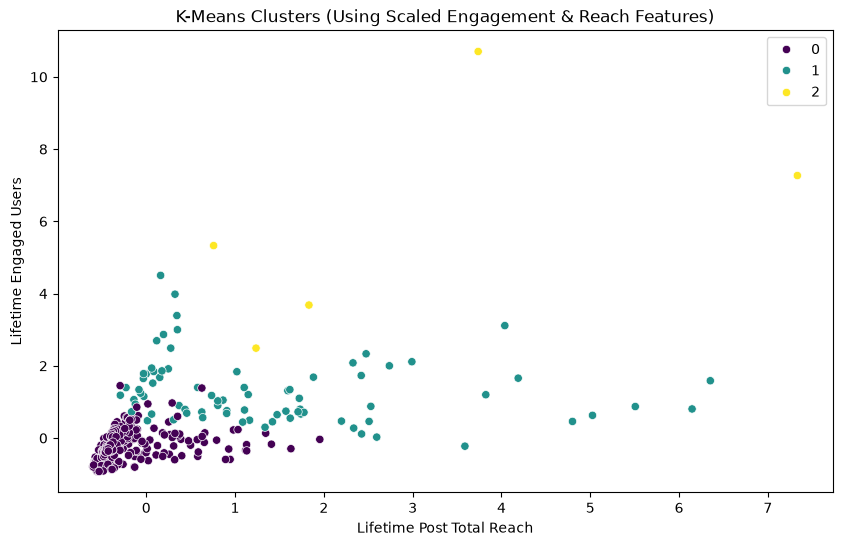

In [13]:
#Apply K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
data['cluster'] = clusters

#Visualization 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters,
    palette='viridis'
)
plt.title("K-Means Clusters (Using Scaled Engagement & Reach Features)")
plt.xlabel(cluster_features[0])
plt.ylabel(cluster_features[1])
plt.show()

In [ ]:

print(data['cluster'].value_counts()) #Gives us an accurate total of the cluster distribution
data.groupby('cluster')[cluster_features].mean() #Interpreting what each cluster represents

cluster
0    417
1     78
2      5
Name: count, dtype: int64


,Lifetime Post Total Reach,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,share
cluster,,,,,,,,
0,-0.296477,-0.310545,540.925659,7556.868106,3991.894484,405.398082,-0.134072,-0.153759
1,1.394030,1.282391,1878.743590,56245.512821,18972.666667,1555.615385,0.295920,0.473422
2,2.979300,5.894179,5455.600000,168964.800000,29651.200000,2920.800000,6.565210,5.438105


*Results*

K‑Means found three natural groups in your data based on: Lifetime Reach, Engaged Users, Consumers , Impressions, Follower Reach , People who engaged, Comments, Shares

cluster

0 ->  417 , mostly low reach/ low engagement posts (purple) - Normal posts

1 ->  78 , a little higher reach or engagement and more spread (green) - Above Average posts

2  ->  5, Highest reach/ engagement (which seem to be the outliers, yellow) - Amazing "viral" posts

Clustering gave us a way to better segment our posts into meaningful behavioral groups. It aided in revealing which posts are typical, which perform well, and which ones likely go viral. The cluster labels can now act as new feature that our supervised modeals can learn from and improve accuracy because our models can now better predict which "type" of post its predicting. 